# **Regression**

## Objectives

*   Fit and evaluate a regression model to predict SalePrice


## Inputs

* outputs/datasets/collection/house_prices_records.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in their respective notebooks.

## Outputs

* Train set (features and target)
* Test set (features and target)
* ML pipeline to predict SalePrice
* labels map
* Feature Importance Plot



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor'

# Load Data

In [4]:
import numpy as np
import pandas as pd
df = (pd.read_csv("outputs/datasets/collection/house_prices_records.csv")
      )

print(df.shape)
df.head(3)


(1460, 24)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


In [5]:
df_modeling = df.copy()
df_modeling.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


We add the binary flags (HasOpenPorch, HasMasonry) before the pipeline.
Pipelines do not support dynamic column creation inside by default — so we do this outside and feed into TrainSet.

In [6]:
# Create binary indicator columns
df_modeling['HasOpenPorch'] = (df_modeling['OpenPorchSF'] > 0).astype(int)
df_modeling['HasMasonry'] = (df_modeling['MasVnrArea'] > 0).astype(int)


---

# MP Pipeline: Regressor

## Create ML pipeline

Note: 

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer, ArbitraryNumberImputer
from feature_engine.selection import DropFeatures
from feature_engine.encoding import OrdinalEncoder
from feature_engine.transformation import (
    PowerTransformer, BoxCoxTransformer, YeoJohnsonTransformer, LogTransformer
)
# ML algorithms
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor


def PipelineOptimization(model):
    # MODELING PIPELINE
    modeling_pipeline = Pipeline([
    
        # --- 1. Data Cleaning ---
        ("drop_features", DropFeatures(features_to_drop=["EnclosedPorch", "WoodDeckSF"])),
        ("median_imputer", MeanMedianImputer(imputation_method="median", variables=[
            "2ndFlrSF", "BedroomAbvGr", "LotFrontage"
        ])),
        ("constant_imputer", ArbitraryNumberImputer(arbitrary_number=1900.0, variables=["GarageYrBlt"])),
        ("mode_imputer", CategoricalImputer(imputation_method="frequent", variables=[
            "BsmtExposure", "BsmtFinType1", "GarageFinish"
        ])),

        # --- 2. Feature Engineering ---
        # 2.1 Drop highly sparse features (already transformed into binary outside)
        ("drop_sparse", DropFeatures(features_to_drop=["OpenPorchSF", "MasVnrArea"])),

        # 2.2 Ordinal Encoding
        ("ordinal_encoder", OrdinalEncoder(encoding_method="arbitrary", variables=[
            "BsmtExposure", "BsmtFinType1", "GarageFinish", "KitchenQual"
        ])),

        # 2.3 Numerical Transformation
        ("power_1stFlrSF", PowerTransformer(variables=["1stFlrSF"])),
        ("yeojohnson_group1", YeoJohnsonTransformer(variables=[
            "BedroomAbvGr", "BsmtFinSF1", "BsmtUnfSF", "GarageArea", "YearBuilt", "YearRemodAdd",
            "GrLivArea", "LotArea", "LotFrontage", "OverallCond", "TotalBsmtSF"
        ])),
        ("log_garageyrblt", LogTransformer(variables=["GarageYrBlt"], base="10")),
        ("boxcox_overallqual", BoxCoxTransformer(variables=["OverallQual"])),

        # 2.4 Drop correlated features (manual protection of important features)
        ("drop_correlated", DropFeatures(features_to_drop=["1stFlrSF", "GarageYrBlt"])),

        # --- 3. Feature Scaling ---
        ("feat_scaling", StandardScaler()),

        # --- 4. Feature Selection (e.g., LassoCV, RandomForest etc.) ---
        ("feat_selection", SelectFromModel(estimator=model)),

        # --- 5. Final Model ---
        ("model", model)
    ])

    return modeling_pipeline


Custom Class for hyperparameter optimisation

In [8]:
from sklearn.model_selection import GridSearchCV


class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model = PipelineOptimization(self.models[key])

            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring)
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches


---

## Split Train Test Set

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.2,
    random_state=0
)

print("* Train set:", X_train.shape, y_train.shape,
      "\n* Test set:",  X_test.shape, y_test.shape)


* Train set: (1168, 23) (1168,) 
* Test set: (292, 23) (292,)


## Grid Search CV - Sklearn

### Use default hyperparameters to find most suitable algorithm

In [10]:
models_quick_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}

Do a hyperparameter optimisation search using default hyperparameters

In [11]:
search = HyperparameterOptimizationSearch(models=models_quick_search, params=params_quick_search)
search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\


Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\


Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\


Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\


Running GridSearchCV for XGBRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\

Check results

In [12]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,0.687196,0.806634,0.876414,0.066019
0,LinearRegression,0.725435,0.783554,0.831805,0.037744
2,RandomForestRegressor,0.688748,0.771163,0.817518,0.047465
5,GradientBoostingRegressor,0.635793,0.768874,0.831192,0.070259
4,AdaBoostRegressor,0.645653,0.752746,0.797178,0.056209
6,XGBRegressor,0.589023,0.66983,0.751455,0.056743
1,DecisionTreeRegressor,0.494971,0.579547,0.667303,0.063698


ExtraTreesRegressor has the highest average R² but also the highest variance (std = 0.066). This could indicate that it’s sensitive to data variation.

LinearRegression shows stable performance (low std = 0.0377) and does surprisingly well, meaning the engineered features capture linear trends effectively.

XGBRegressor and DecisionTreeRegressor underperform here, which might suggest that either:

* The hyperparameters are suboptimal,

* The models are overfitting (especially for trees),

* Or the ensemble power of RandomForest/ExtraTrees outperforms single models.

### Do an extensive search on the most suitable model to find the best hyperparameter configuration.

Define model and parameters, for Extensive Search

In [13]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
}

# documentation to help on hyperparameter list: 
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

# We will not conduct an extensive search, since the focus
# is on how to combine all knowledge in an applied project.
# In a workplace project, you may consider more hyperparameters and spend more time in this step

params_search = {
    "ExtraTreesRegressor": {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],
        'model__criterion': ['squared_error', 'absolute_error']
    }
}

Extensive GridSearch CV

In [14]:
search = HyperparameterOptimizationSearch(models=models_search, params=params_search)
search.fit(X_train, y_train, scoring = 'r2', n_jobs=-1, cv=3, verbose=1)


Running GridSearchCV for ExtraTreesRegressor 

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\

Check results

In [15]:
grid_search_summary, grid_search_pipelines = search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__criterion,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators
219,ExtraTreesRegressor,0.799563,0.835899,0.864693,0.027119,absolute_error,None,sqrt,1,5,100
246,ExtraTreesRegressor,0.799563,0.835899,0.864693,0.027119,absolute_error,None,log2,1,5,100
408,ExtraTreesRegressor,0.799563,0.835894,0.864676,0.027113,absolute_error,30,log2,1,5,100
381,ExtraTreesRegressor,0.799563,0.835894,0.864676,0.027113,absolute_error,30,sqrt,1,5,100
327,ExtraTreesRegressor,0.801356,0.835628,0.86313,0.025669,absolute_error,20,sqrt,1,5,100
...,...,...,...,...,...,...,...,...,...,...,...
293,ExtraTreesRegressor,0.727883,0.773196,0.817681,0.036665,absolute_error,10,sqrt,4,5,300
291,ExtraTreesRegressor,0.72784,0.773043,0.813595,0.035163,absolute_error,10,sqrt,4,5,100
318,ExtraTreesRegressor,0.72784,0.773043,0.813595,0.035163,absolute_error,10,log2,4,5,100
315,ExtraTreesRegressor,0.72784,0.773043,0.813595,0.035163,absolute_error,10,log2,4,2,100


Check the best model

In [16]:
best_model = grid_search_summary.iloc[0, 0]
best_model

'ExtraTreesRegressor'

Parameters for best model

In [17]:
grid_search_pipelines[best_model].best_params_

{'model__criterion': 'absolute_error',
 'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

Define the best regressor, based on search

In [18]:
best_regressor_pipeline = grid_search_pipelines[best_model].best_estimator_
best_regressor_pipeline

Pipeline(steps=[('drop_features',
                 DropFeatures(features_to_drop=['EnclosedPorch',
                                                'WoodDeckSF'])),
                ('median_imputer',
                 MeanMedianImputer(variables=['2ndFlrSF', 'BedroomAbvGr',
                                              'LotFrontage'])),
                ('constant_imputer',
                 ArbitraryNumberImputer(arbitrary_number=1900.0,
                                        variables=['GarageYrBlt'])),
                ('mode_imputer',
                 CategoricalImputer(imputation_method='frequent',
                                    varia...
                 BoxCoxTransformer(variables=['OverallQual'])),
                ('drop_correlated',
                 DropFeatures(features_to_drop=['1stFlrSF', 'GarageYrBlt'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=0))),
                ('model',
                 ExtraTreesRegressor(criterion='absolute_error',
                                     max_features='sqrt', min_samples_split=5,
                                     random_state=0))])

## Assess feature importance

* These are the 5 most important features in descending order:
['OverallQual', 'GrLivArea', 'YearBuilt', 'GarageArea', 'TotalBsmtSF']


c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\feature_engine\encoding\base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
c:\Users\farib\AppData\Local\Programs\Python\Python312\Lib\site-packages\

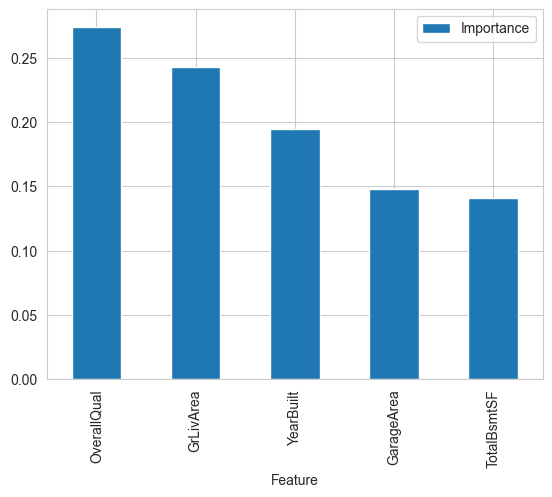

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Extract steps before scaling (up to but not including 'feat_selection')
data_cleaning_feat_eng_steps = 12
X_transformed = Pipeline(best_regressor_pipeline.steps[:data_cleaning_feat_eng_steps]).transform(X_train)

# Manually assign column names from X_train, after all previous transformations
# (Assumes that the transformation preserves column order)
columns_before_selection = X_train.columns

# If your pipeline drops/adds columns, it's safer to extract names before scaling:
# Step 1: run pipeline up to just before 'feat_scaling'
pipeline_before_scaling = Pipeline(best_regressor_pipeline.steps[:11])  # up to 'drop_correlated'
X_engineered = pipeline_before_scaling.transform(X_train)

# Step 2: wrap in DataFrame to keep column names
X_engineered_df = pd.DataFrame(X_engineered, columns=X_engineered.columns)

# Step 3: get support from SelectFromModel
mask = best_regressor_pipeline['feat_selection'].get_support()
best_features = X_engineered_df.columns[mask].to_list()

# Step 4: plot feature importances
df_feature_importance = pd.DataFrame({
    'Feature': best_features,
    'Importance': best_regressor_pipeline['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print(f"* These are the {len(best_features)} most important features in descending order:\n"
      f"{df_feature_importance['Feature'].to_list()}")

# Plot
df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.show()


---

# Push files to Repo

* If you do not need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.